In [1]:
import sys
sys.path.append("../")  # Adds the scripts folder to the Python path

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("../../data/processed/Final_Solar_Data_Model.csv", parse_dates=["Date"])
df = df.set_index("Date").asfreq("MS")  # Ensure monthly start freq

# Initial check
print(f" Final shape (before dropna): {df.shape}")
print(f" Date range: {df.index.min().date()} {df.index.max().date()}")
print(" First few rows:")
print(df.head())

# Drop NA values
df.dropna(inplace=True)
print(f" Final shape (after dropna): {df.shape}")

 Final shape (before dropna): (168, 9)
 Date range: 2011-01-01 2024-12-01
 First few rows:
            Solar_GWh  Solar_GWh_Lag1  Solar_GWh_Lag2  Solar_GWh_Lag12  \
Date                                                                     
2011-01-01        0.0             0.0             0.0              0.0   
2011-02-01        0.0             0.0             0.0              0.0   
2011-03-01        0.0             0.0             0.0              0.0   
2011-04-01        0.0             0.0             0.0              0.0   
2011-05-01        0.0             0.0             0.0              0.0   

            Solar_GWh_RollingMean3  Solar_Radiation_MJ_per_m2  \
Date                                                            
2011-01-01                     0.0                  2722785.5   
2011-02-01                     0.0                  4892891.0   
2011-03-01                     0.0                 10031971.0   
2011-04-01                     0.0                 15662278.0   


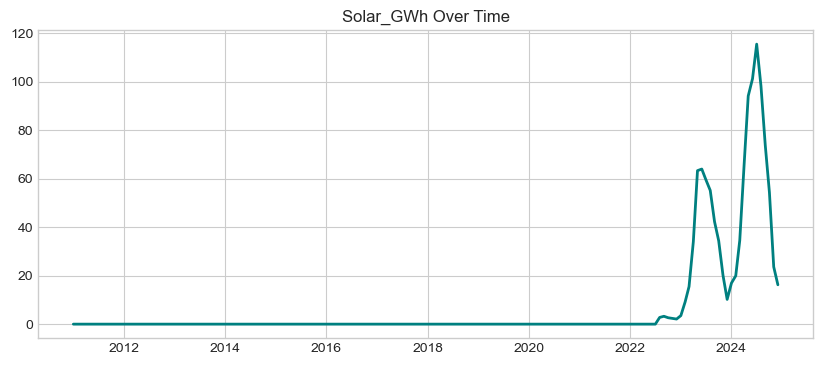

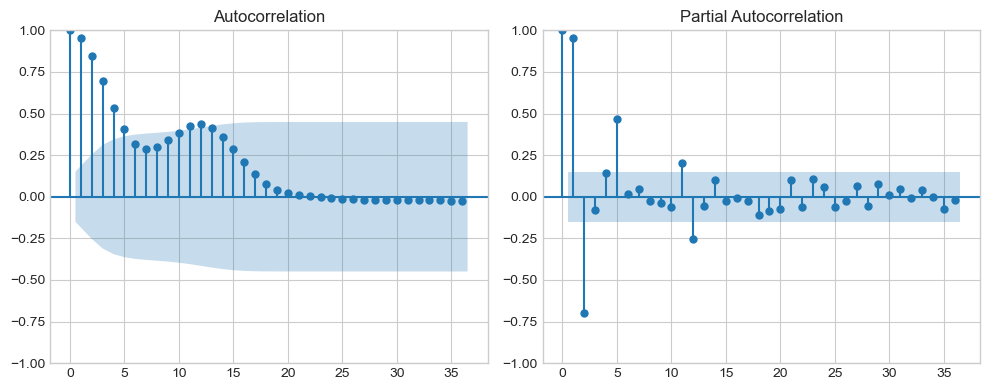

   Test  Statistic   p-value
0   ADF   0.419213  0.982199
1  KPSS   0.758150  0.010000
2   ADF  -1.953742  0.307216
3  KPSS   0.026292  0.100000

 Rule-of-thumb:
- If ADF p<0.05 → stationary
- If KPSS p>0.05 → stationary


C:\Users\sfarh\AppData\Local\Temp\ipykernel_24308\99309138.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression="c", nlags="auto")
C:\Users\sfarh\AppData\Local\Temp\ipykernel_24308\99309138.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression="c", nlags="auto")


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

TARGET = "Solar_GWh"
y = df[TARGET]

#Teal theme
plt.style.use("seaborn-v0_8-whitegrid")
teal = "#008080"

# Helpers
def adf_test(series):
    result = adfuller(series, autolag="AIC")
    return {"Test": "ADF", "Statistic": result[0], "p-value": result[1]}

def kpss_test(series):
    result = kpss(series, regression="c", nlags="auto")
    return {"Test": "KPSS", "Statistic": result[0], "p-value": result[1]}

# Line plot
plt.figure(figsize=(10, 4))
plt.plot(y, color=teal, lw=2)
plt.title(f"{TARGET} Over Time")
plt.savefig("solar_trend_check.png", dpi=300)
plt.show()
plt.close()

# ACF & PACF
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(y, ax=ax[0], lags=36)
plot_pacf(y, ax=ax[1], lags=36)
plt.tight_layout()
plt.savefig("solar_acf_pacf.png", dpi=300)
plt.show()
plt.close()

# Differenced variants
y_diff1 = y.diff().dropna()

# Run tests
results = [
    adf_test(y),
    kpss_test(y),
    adf_test(y_diff1),
    kpss_test(y_diff1)
]
summary_df = pd.DataFrame(results)
print(summary_df)

# Suggestion
print("\n Rule-of-thumb:")
print("- If ADF p<0.05 → stationary")
print("- If KPSS p>0.05 → stationary")


SARIMAX Solar (no exog) order search + diagnostics

 Train period: 2022-08-01 → 2023-12-01
 Observations: 17 months
Searching for best SARIMAX order (AIC)

 Best order: (2, 1, 0), seasonal: (0, 1, 0, 12), AIC: -34.12


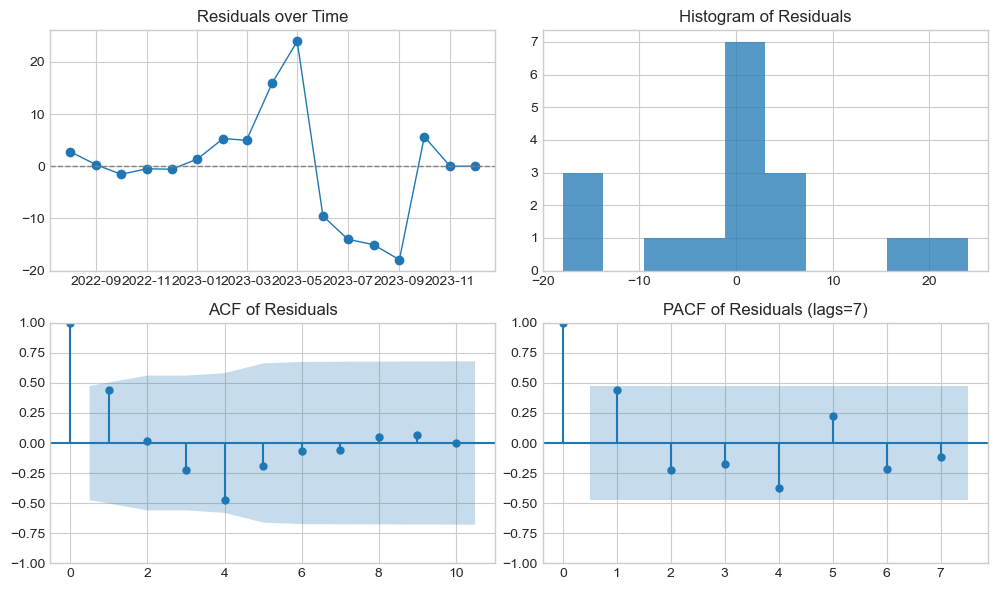

 Diagnostics saved to: C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_Solar\sarimax_solar_noexog_light_diagnostics.png


In [ ]:
#SARIMAX (Solar, no exog) — Order Search + Diagnostics
import itertools, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Config 
TARGET = "Solar_GWh"
TRAIN_START, TRAIN_END = "2022-08-01", "2023-12-01"
FIG_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_Solar\sarimax_solar_noexog_light_diagnostics.png"

warnings.filterwarnings("ignore")

# Train-only series
y_train = (
    df[[TARGET]]
    .asfreq("MS") # monthly start freq
    .loc[TRAIN_START:TRAIN_END, TARGET]
    .dropna()
)

print(f" Train period: {y_train.index.min().date()} → {y_train.index.max().date()}")
print(f" Observations: {len(y_train)} months")

# Parameter grid (small & sensible for monthly data)
p = q = [0, 1, 2]
d = [1]            # use d=1 per your stationarity check
P = Q = [0, 1]
D = [1]
s = 12             # monthly seasonality

non_seasonal = list(itertools.product(p, d, q))
seasonal     = list(itertools.product(P, D, Q, [s]))

best_aic = np.inf
best_order = None
best_seasonal = None
best_res = None

print("Searching for best SARIMAX order (AIC)")
for order in non_seasonal:
    for seas in seasonal:
        try:
            model = sm.tsa.statespace.SARIMAX(
                y_train,
                order=order,
                seasonal_order=seas,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic, best_order, best_seasonal, best_res = res.aic, order, seas, res
        except Exception:
            continue

print(f"\n Best order: {best_order}, seasonal: {best_seasonal}, AIC: {best_aic:.2f}")

# Lightweight residual diagnostics (train fit)
resid = best_res.resid

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

# Residuals over time
axes[0].plot(resid, marker='o', linewidth=1)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title("Residuals over Time")

# Histogram of residuals
axes[1].hist(resid, bins=10, alpha=0.75)
axes[1].set_title("Histogram of Residuals")

# Compute max allowed lags for PACF 
max_pacf_lags = max(1, (len(resid) // 2) - 1)

# ACF of residuals
plot_acf(resid, lags=min(10, len(resid)-1), ax=axes[2])
axes[2].set_title("ACF of Residuals")

# PACF of residuals (auto-adjusted lags)
plot_pacf(resid, lags=max_pacf_lags, ax=axes[3])
axes[3].set_title(f"PACF of Residuals (lags={max_pacf_lags})")

plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(" Diagnostics saved to:", FIG_PATH)

In [6]:
# SARIMAX (Solar, no exog) retrain & test
import time
import joblib
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score

# Locked params from search
ORDER  = (2, 1, 0)
SORDER = (0, 1, 0, 12)
TARGET = "Solar_GWh"

# Chronological split
y_train = df.loc["2022-08-01":"2023-12-01", TARGET].astype(float)
y_test  = df.loc["2024-01-01":"2024-12-01", TARGET].astype(float)

print(f"Train: {y_train.index.min().date()} → {y_train.index.max().date()} ({len(y_train)} months)")
print(f"Test:  {y_test.index.min().date()} → {y_test.index.max().date()} ({len(y_test)} months)")

# Fit model
t0 = time.time()
model = SARIMAX(
    endog=y_train,
    order=ORDER,
    seasonal_order=SORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
train_time = time.time() - t0

# Forecast
fc = model.get_forecast(steps=len(y_test))
y_pred = pd.Series(fc.predicted_mean, index=y_test.index)
ci90   = fc.conf_int(alpha=0.10) 

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
r2   = r2_score(y_test, y_pred)

print(f"\nTest Metrics:")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")
print(f"Training Time: {train_time:.2f} sec")

# Save model
model_path = "SARIMAX_Solar_no_exog.joblib"
joblib.dump(model, model_path)
print(f" Model saved to {model_path}")


Train: 2022-08-01 → 2023-12-01 (17 months)
Test:  2024-01-01 → 2024-12-01 (12 months)

Test Metrics:
MAE  = 130.18
RMSE = 147.53
R²   = -16.429
Training Time: 0.05 sec
 Model saved to SARIMAX_Solar_no_exog.joblib


In [ ]:
from log_utils import log_model_performance, save_log_to_csv
class SARIMAXAdapter:
    def __init__(self, fitted_model):
        self.model = fitted_model
    def predict(self, X):
        steps = len(X)
        return self.model.get_forecast(steps=steps).predicted_mean.values

X_train_dummy = pd.DataFrame({"dummy": [0] * len(y_train)})
X_test_dummy  = pd.DataFrame({"dummy": [0] * len(y_test)})


log_dict = log_model_performance(
    model_name="SARIMAX_Solar_no_exog",
    target_variable=TARGET,
    X_train=X_train_dummy,
    X_test=X_test_dummy,
    y_test=y_test.values,
    y_pred=y_pred.values,
    model_object=SARIMAXAdapter(res),
    training_time_sec=train_time,
    dataset_name="Final_Model_Solar.csv",
    tuning_type="Locked orders (from AIC search)",
    gpu_used="NVIDIA GeForce RTX 2050",
    extra_notes=f"order={ORDER}, seasonal_order={SORDER}; no exogenous variables"
)
save_log_to_csv(log_dict)


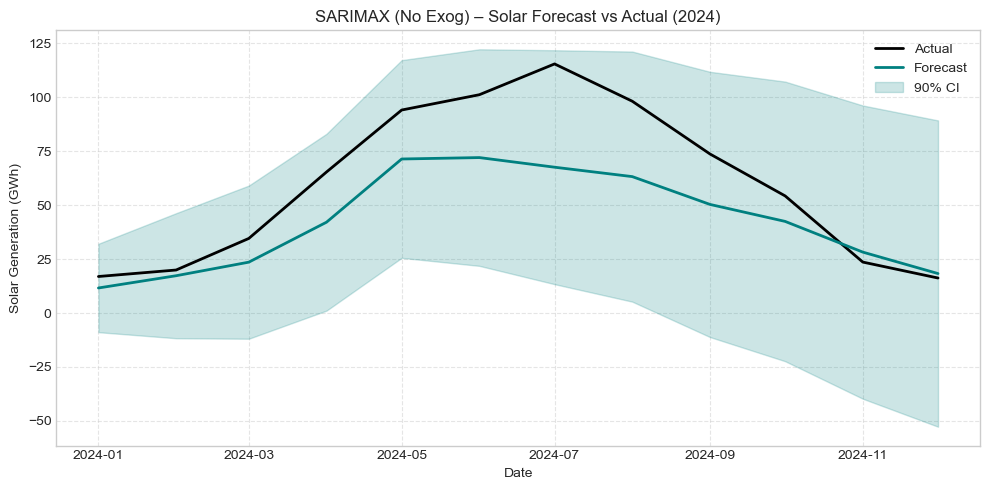

In [ ]:
import matplotlib.pyplot as plt
import joblib

# --- Paths ---
FIG_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_Solar\solar_sarimax_forecast_ci.png"
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\SARIMAX_Solar_no_exog.joblib"

# --- Load trained SARIMAX model ---
model = joblib.load(MODEL_PATH)

# --- Get forecast and 90% CI for test period ---
fc = model.get_prediction(start=y_test.index[0], end=y_test.index[-1])
ci90 = fc.conf_int(alpha=0.10)

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test, label="Actual", color="black", lw=2)
plt.plot(y_test.index, fc.predicted_mean, label="Forecast", color="teal", lw=2)
plt.fill_between(y_test.index, ci90.iloc[:, 0], ci90.iloc[:, 1],
                 color="teal", alpha=0.2, label="90% CI")

plt.title("SARIMAX (No Exog) – Solar Forecast vs Actual (2024)")
plt.xlabel("Date")
plt.ylabel("Solar Generation (GWh)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300)
plt.show()


SARIMAX (lagged exog) — Order Search + Diagnostics (train only)

In [ ]:
# SARIMAX (Lagged Exog)
import time, joblib, numpy as np, pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score
from log_utils import log_model_performance, save_log_to_csv
import matplotlib.pyplot as plt, os

# Config
TARGET = "Solar_GWh"
EXOG_COLS = ["Solar_GWh_Lag1","Solar_GWh_Lag2","Solar_GWh_Lag12", ]   # lagged-only exog
ORDER, SORDER = (1, 1, 0), (0, 1, 0, 12)
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\SARIMAX_Solar_lagged_exog.joblib"
FIG_PATH   = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_Solar\sarimax_lagged_exog_forecast_2024.png"
os.makedirs(os.path.dirname(FIG_PATH), exist_ok=True)

# Split
train = df.loc["2022-08-01":"2023-12-01", [TARGET]+EXOG_COLS].dropna()
test  = df.loc["2024-01-01":"2024-12-01",  [TARGET]+EXOG_COLS].dropna()

y_train, X_train = train[TARGET].astype(float), train[EXOG_COLS].astype(float)
y_test,  X_test  = test[TARGET].astype(float),  test[EXOG_COLS].astype(float)

print(f"Train: {y_train.index.min().date()} → {y_train.index.max().date()} | n={len(y_train)}")
print(f"Test : {y_test.index.min().date()}  → {y_test.index.max().date()}  | n={len(y_test)}")

# Fit
t0 = time.time()
res = SARIMAX(y_train, exog=X_train, order=ORDER, seasonal_order=SORDER,
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
train_time = time.time() - t0

# Forecast (multi-step with exog)
fc = res.get_forecast(steps=len(y_test), exog=X_test)
y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)
ci90   = fc.conf_int(alpha=0.10)

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(np.mean((y_test - y_pred)**2)))
r2   = r2_score(y_test, y_pred)
print(f"Test  MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")

# Save model
joblib.dump(res, MODEL_PATH)
print(" Saved:", MODEL_PATH)

#  Adapter so logger can call .predict(exog)
class SARIMAXAdapter:
    def __init__(self, fitted): self.m = fitted
    def predict(self, X):       return self.m.get_forecast(steps=len(X), exog=X).predicted_mean.values

# Log (JSON + CSV)
log_dict = log_model_performance(
    model_name="SARIMAX_Solar_lagged_exog",
    target_variable=TARGET,
    X_train=X_train, X_test=X_test,
    y_test=y_test.values, y_pred=y_pred.values,
    model_object=SARIMAXAdapter(res),
    training_time_sec=train_time,
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type=f"Locked orders from search: order={ORDER}, seasonal_order={SORDER}",
    gpu_used="NVIDIA GeForce RTX 2050",
    prediction_interval_width=float(np.mean(ci90.iloc[:,1] - ci90.iloc[:,0])),
    extra_notes=f"Exog={EXOG_COLS}"
)
save_log_to_csv(log_dict)

# Actual vs Predicted (2024) with 90% CI
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual", color="black", lw=2)
plt.plot(y_pred.index, y_pred, label="Forecast", color="teal", lw=2)
plt.fill_between(y_pred.index, ci90.iloc[:,0], ci90.iloc[:,1], color="teal", alpha=0.2, label="90% CI")
plt.title("SARIMAX (Lagged Exog) — Solar Forecast vs Actual (2024)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, linestyle="--", alpha=0.5); plt.legend(); plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300); plt.show()
print(" Figure saved to:", FIG_PATH)


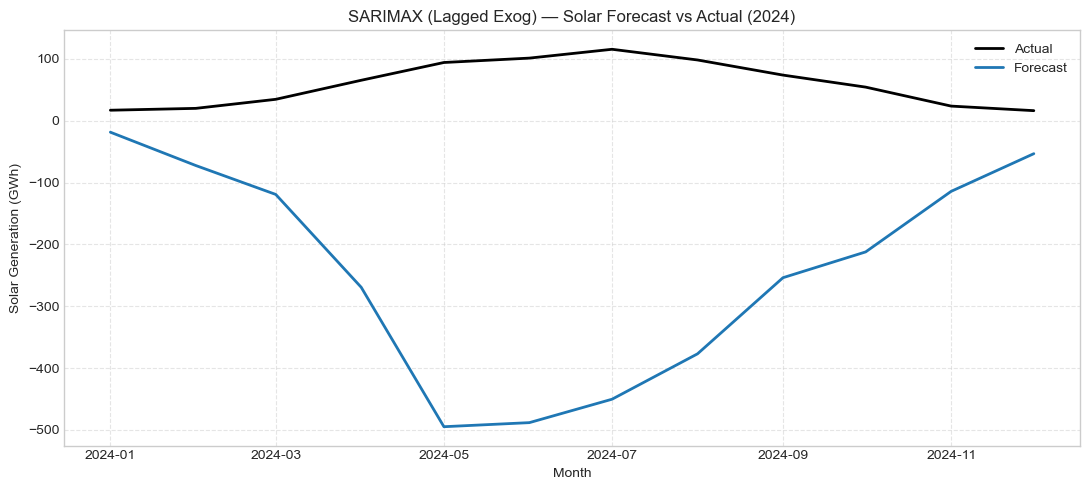

Saved figure to: C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_Solar\sarimax_lagged_exog_final_noci.png


In [ ]:
# SARIMAX (Lagged Exog) — Forecast vs Actual (2024), no CI
FIG_PATH_LE = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_Solar\sarimax_lagged_exog_final_noci.png"
os.makedirs(os.path.dirname(FIG_PATH_LE), exist_ok=True)

idx = y_test.index
actual   = y_test.reindex(idx).values
forecast = y_pred.reindex(idx).values

plt.figure(figsize=(11,5))
plt.plot(idx, actual,   label="Actual",   color="black",   lw=2)
plt.plot(idx, forecast, label="Forecast", color="#1f77b4", lw=2)
plt.title("SARIMAX (Lagged Exog) — Solar Forecast vs Actual (2024)")
plt.xlabel("Month"); plt.ylabel("Solar Generation (GWh)")
plt.grid(True, linestyle="--", alpha=0.5); plt.legend(); plt.tight_layout()
plt.savefig(FIG_PATH_LE, dpi=600); plt.show()
print("Saved figure to:", FIG_PATH_LE)


ARIMAX — Best order search (AIC) on train only + diagnostics

In [ ]:
# ARIMAX (non-seasonal) — Order Search + Diagnostics
import itertools, warnings
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

# Config
TARGET = "Solar_GWh"
EXOG_COLS = ["Solar_GWh_Lag1","Solar_GWh_Lag12","Solar_Radiation_MJ_per_m2","Solar_Capacity_MW"]
FIG_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\SARIMAX_Solar\arimax_solar_order_search_diagnostics.png"

# Train
train = df.loc["2022-08-01":"2023-12-01", [TARGET] + EXOG_COLS].dropna()
y_train = train[TARGET].astype(float)
X_train = train[EXOG_COLS].astype(float)

print(f" Train period: {y_train.index.min().date()} → {y_train.index.max().date()}")
print(f" Observations: {len(y_train)}")
print(" Searching ARIMAX (non-seasonal) orders by AIC.")

# Small grid for (p,d,q), non-seasonal only 
p, d, q = [0,1,2], [1], [0,1,2]
orders = list(itertools.product(p, d, q))

best_aic, ARIMAX_ORDER, arimax_res_train = np.inf, None, None

for order in orders:
    try:
        res = sm.tsa.statespace.SARIMAX(
            endog=y_train, exog=X_train,
            order=order, seasonal_order=(0,0,0,0),  # force ARIMAX (no seasonality)
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False)
        if res.aic < best_aic:
            best_aic, ARIMAX_ORDER, arimax_res_train = res.aic, order, res
    except Exception:
        pass

print(f"\n Best ARIMAX order: {ARIMAX_ORDER}, AIC: {best_aic:.2f}")

# Residual diagnostics 
resid = arimax_res_train.resid.dropna()
max_lags = max(1, min(10, len(resid)//2 - 1))  # safe cap for short series

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
axes[0,0].plot(resid, marker="o", lw=1)
axes[0,0].axhline(0, ls="--", c="gray", lw=1)
axes[0,0].set_title("Residuals Over Time")

axes[0,1].hist(resid, bins=10, edgecolor="white", alpha=0.9)
axes[0,1].set_title("Histogram of Residuals")

plot_acf(resid,  lags=max_lags, ax=axes[1,0]); axes[1,0].set_title(f"ACF (lags={max_lags})")
plot_pacf(resid, lags=max_lags, ax=axes[1,1], method="ywm"); axes[1,1].set_title(f"PACF (lags={max_lags})")

plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300)
plt.show()
print(" Saved diagnostics to:", FIG_PATH)

# Ljung–Box (white-noise check)
lb = acorr_ljungbox(resid, lags=[6,9,12], return_df=True)
print("\n=== Ljung–Box (H0: residuals are white noise) ===")
print(lb)

In [ ]:
# ARIMAX (non-seasonal, with exog)
import time, joblib, numpy as np, pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, r2_score
from log_utils import log_model_performance, save_log_to_csv

# Config 
TARGET = "Solar_GWh"
EXOG_COLS = ["Solar_GWh_Lag1", "Solar_GWh_Lag12", "Solar_Radiation_MJ_per_m2", "Solar_Capacity_MW"]
ORDER = (0, 1, 2)   # from AIC search
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\ARIMAX_Solar_exog.joblib"

# Split (locked)
train = df.loc["2022-08-01":"2023-12-01", [TARGET] + EXOG_COLS].dropna()
test  = df.loc["2024-01-01":"2024-12-01",  [TARGET] + EXOG_COLS].dropna()

y_train, X_train = train[TARGET].astype(float), train[EXOG_COLS].astype(float)
y_test,  X_test  = test[TARGET].astype(float),  test[EXOG_COLS].astype(float)

print(f"Train: {y_train.index.min().date()} → {y_train.index.max().date()} | n={len(y_train)}")
print(f"Test : {y_test.index.min().date()}  → {y_test.index.max().date()}  | n={len(y_test)}")

# Fit 
t0 = time.time()
res = SARIMAX(y_train, exog=X_train, order=ORDER, seasonal_order=(0,0,0,0),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
train_time = time.time() - t0

# Forecast 2024
fc = res.get_forecast(steps=len(y_test), exog=X_test)
y_pred = pd.Series(fc.predicted_mean.values, index=y_test.index)
ci90 = fc.conf_int(alpha=0.10)

# Metrics 
mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(np.mean((y_test - y_pred) ** 2)))
r2   = r2_score(y_test, y_pred)
print(f"Test MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")

# Save model
joblib.dump(res, MODEL_PATH)
print(" Saved:", MODEL_PATH)

# Adapter for logger (sklearn-like .predict on exog) 
class ARIMAXAdapter:
    def __init__(self, fitted): self.m = fitted
    def predict(self, X):       return self.m.get_forecast(steps=len(X), exog=X).predicted_mean.values

# Log to JSON + CSV 
log_dict = log_model_performance(
    model_name="ARIMAX_Solar_exog",
    target_variable=TARGET,
    X_train=X_train, X_test=X_test,
    y_test=y_test.values, y_pred=y_pred.values,
    model_object=ARIMAXAdapter(res),
    training_time_sec=train_time,
    dataset_name="Final_Solar_Data_Model.csv",
    tuning_type=f"ARIMAX AIC search; order={ORDER}",
    gpu_used="NVIDIA GeForce RTX 2050",
    prediction_interval_width=float((ci90.iloc[:,1] - ci90.iloc[:,0]).mean()),
    extra_notes=f"Non-seasonal ARIMAX with exog={EXOG_COLS}"
)
save_log_to_csv(log_dict)


y_test_arimax = y_test.copy()
y_pred_arimax = y_pred.copy()
ci90_arimax   = ci90.copy()


In [ ]:
# ARIMAX (non-seasonal) — Plots
import joblib, pandas as pd, matplotlib.pyplot as plt

FIG_DIR    = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\ARIMAX_Solar"
MODEL_PATH = r"C:\Projects\GitHub\Ireland-energy-forecast\models\ARIMAX_Solar_exog.joblib"

res = joblib.load(MODEL_PATH)

# Forecast vs Actual (2024) w/ 90% CI
fc   = res.get_forecast(steps=len(y_test), exog=X_test)
ci90 = fc.conf_int(alpha=0.10)

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual", color="black", lw=2)
plt.plot(y_test.index, fc.predicted_mean, label="Forecast", color="#1f77b4", lw=2)
plt.fill_between(y_test.index, ci90.iloc[:,0], ci90.iloc[:,1], color="#007f7f", alpha=0.18, label="90% CI")
plt.title("ARIMAX (non-seasonal) — Solar Forecast vs Actual (2024)")
plt.xlabel("Date"); plt.ylabel("Solar Generation (GWh)")
plt.legend(); plt.grid(True, alpha=0.25); plt.tight_layout()
plt.savefig(fr"{FIG_DIR}\arimax_solar_forecast_ci.png", dpi=300); plt.show()


In [ ]:
# ARIMAX (non-seasonal) Test Residual Diagnostics 
import os, numpy as np, matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

FIG_DIR = r"C:\Projects\GitHub\Ireland-energy-forecast\outputs\figures\ARIMAX_Solar"
os.makedirs(FIG_DIR, exist_ok=True)

# Test residuals
res_test = (y_test - y_pred).astype(float)
max_lags = max(1, min(12, len(res_test)//2 - 1))  # safe for short series

# Residuals over time
plt.figure(figsize=(10,4))
plt.plot(y_test.index, res_test, marker="o", lw=1.5)
plt.axhline(0, ls="--", c="gray", lw=1)
plt.title("ARIMAX — Residuals Over Time (Test 2024)")
plt.xlabel("Month"); plt.ylabel("Residual (GWh)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "arimax_residuals_over_time.png"), dpi=300)
plt.show()
